#### Open and plot regions of interest (ROI)

- Seven different regions of interest within the Norkyst model grid were defined;
- They will be used as seeding locations for initial position of virtual particles


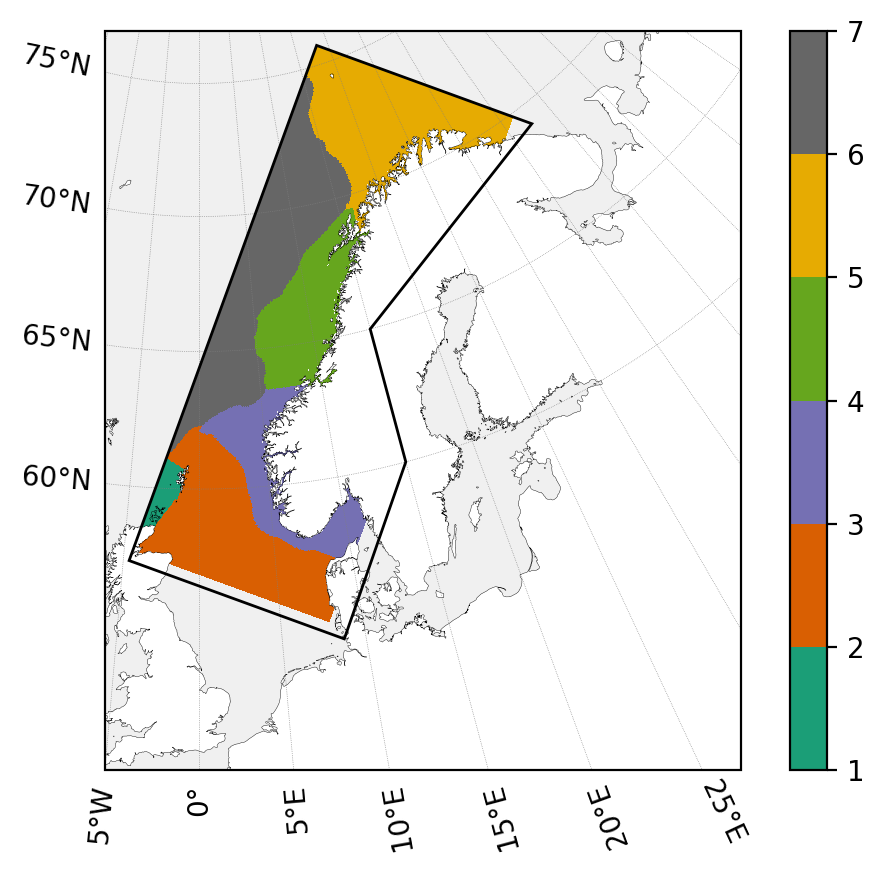

In [2]:
import xarray as xr
import numpy as np
import cartopy.crs as ccrs # Geospatial data processing
import cartopy.feature as cfeature # Features (land, boundaries) from cartopy
import cartopy.io.shapereader as shpreader
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import matplotlib.cm as cm

path_to = './datasets/roi/roi.nc'
df = xr.open_dataset(path_to, engine='netcdf4')

# Stack grid into 1D
stacked = df.stack(points=("eta_rho", "xi_rho"))

# Drop missing region values (if any)
stacked = stacked.dropna(dim="points", subset=["region"])

########################################
### Plot selected random points here ###
########################################

lon_nk = [-4.61489652, 18.32942509, 37.55453838, 15, 15, 8.69997235, -4.61489652]
lat_nk = [57.34412441, 75.72596758, 69.24523963, 65, 60, 54.29489733,57.34412441]

# Define Cartopy object
projection = ccrs.Stereographic(central_latitude=90, central_longitude=0, \
    false_easting=0, false_northing=0, true_scale_latitude=75, globe=None)


fig = plt.figure(dpi=200)
ax = plt.axes(projection=projection)
transform = ccrs.PlateCarree()._as_mpl_transform(ax)

# Degine colormap for the different areas 
cmap = plt.get_cmap("Dark2", 7)
bounds = np.arange(1, 7 + 1, 1)
norm = mcolors.BoundaryNorm(bounds, cmap.N)

### Plot all the areas here ###
mesh = ax.pcolormesh(
    df["lon"],
    df["lat"],
    df["region"],
    cmap=cmap,
    norm=norm,
    shading="nearest",
    transform=ccrs.PlateCarree()
)

### Plot some other stuff
zipped_bep = zip(lon_nk, lat_nk)
poly_beps = mpatches.Polygon(list(zipped_bep), closed=True,\
                        facecolor='none', edgecolor='black', lw=1, transform=ccrs.Geodetic(), zorder=2005) # it has to be clockwise, LLC first
ax.add_patch(poly_beps)


### Add color, land etc ###
ax.add_feature(cfeature.LAKES, facecolor=("white"))
ax.add_feature(cfeature.OCEAN, facecolor=("#f0f0f0"))
ax.coastlines(resolution='10m', color='black', linewidth=.15, zorder=2002)

# Set extent
ax.set_extent([-5, 30, 50, 75], crs=ccrs.PlateCarree())

# Adjust grid labels
gl = ax.gridlines(crs=ccrs.PlateCarree(), color='gray', linestyle='dotted', linewidth=0.25, draw_labels=True,\
     dms=True, x_inline=False, y_inline=False, alpha=1, zorder=2003) # Display lat/lon grid

gl.top_labels = False
gl.bottom_labels =True
gl.left_labels = True
gl.right_labels = False

gl.ylocator = mticker.FixedLocator(np.arange(60, 95, 5))
gl.xlocator = mticker.FixedLocator(np.arange(-180, 180, 5))

# Inser colorbar
plt.colorbar(mesh)

plt.show()



#### Selecting random points

- Within each region (discarding #1), we will select random points;
- These random points will represent the initial position of our virtual particles
- Since we are aiming for 5-day long simulations, we have to ensure that the particles don't get stranded quickly.
  - Only consider valid points 30 km away from the coast. If not, repeat the sampling.


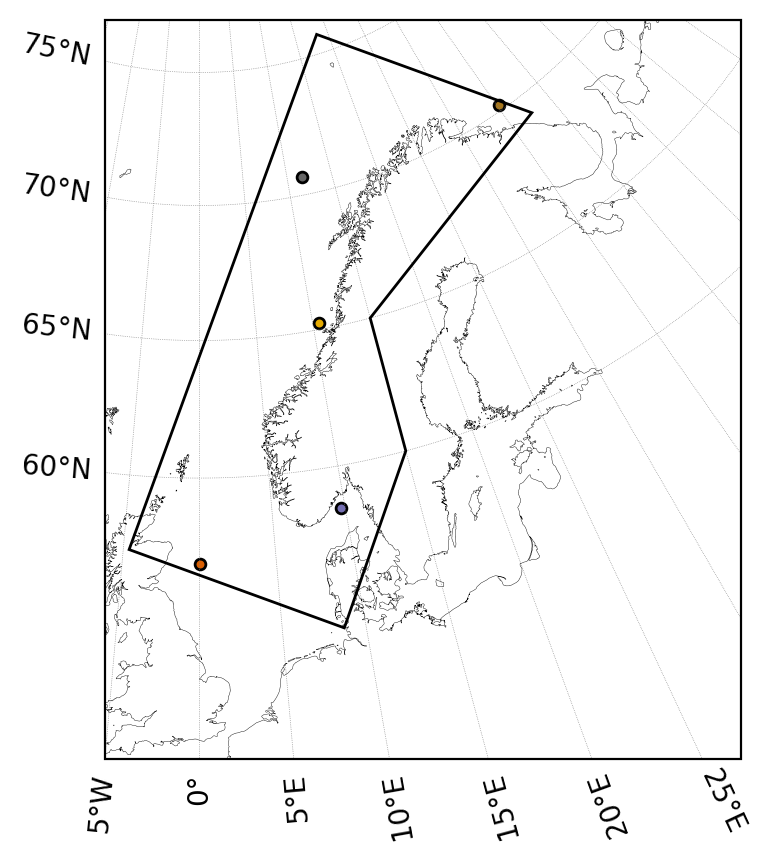

In [9]:
from shapely.geometry import box, Polygon, Point, MultiPolygon, MultiLineString
from shapely.ops import unary_union
from scipy.spatial import cKDTree
from pyproj import Proj, Geod

# ------------------------------------------------------ #
# --- Define random points at the domain of interest --- #
# ------------------------------------------------------ #

def random_point(seeder, stacked):
    # rng = np.random.default_rng(seed=42)  # reproducible
    rng = np.random.default_rng(seed=seeder) # random
    
    n_points = 1  # number of random points per region
    samples = {}
    
    #for r in range(1, 21):
    for r in [2,3,4,5,6]: # # [1,2,3,4,5,7,8, 10, 11, 12,14,17,18,19] Selected areas
        region_points = stacked.where(stacked["region"] == r, drop=True)
    
        if region_points.points.size == 0:
            continue
    
        idx = rng.choice(
            region_points.points.size,
            size=min(n_points, region_points.points.size),
            replace=False,
        )
    
        samples[r] = {
            "lat": region_points["lat"].values[idx],
            "lon": region_points["lon"].values[idx],
        }

    return samples

# ------------------------------- #
# --- Check distance to coast --- #
# ------------------------------- #

def check_distance_regional_coast(lon, lat, padding_deg=2.0):
    lon = np.asarray(lon)
    lat = np.asarray(lat)

    # --------------------------------------------------
    # Bounding box (expanded slightly)
    # --------------------------------------------------
    lon_min = lon.min() - padding_deg
    lon_max = lon.max() + padding_deg
    lat_min = lat.min() - padding_deg
    lat_max = lat.max() + padding_deg

    bbox = box(lon_min, lat_min, lon_max, lat_max)

    # --------------------------------------------------
    # Load coastline geometries
    # --------------------------------------------------
    coast_feature = cfeature.NaturalEarthFeature(
        category="physical",
        name="coastline",
        scale="10m",
    )

    coast_geoms = list(coast_feature.geometries())

    # --------------------------------------------------
    # Clip coastlines to bounding box
    # --------------------------------------------------
    clipped_lines = []
    for geom in coast_geoms:
        if geom.intersects(bbox):
            clipped = geom.intersection(bbox)
            if not clipped.is_empty:
                clipped_lines.append(clipped)

    coastline = unary_union(clipped_lines)

    # --------------------------------------------------
    # Sample coastline
    # --------------------------------------------------
    sample_res = 0.0001  # ~100 m

    coast_points = []

    def sample_line(line):
        coords = np.asarray(line.coords)
        for i in range(len(coords) - 1):
            x0, y0 = coords[i]
            x1, y1 = coords[i + 1]
            n = max(int(np.hypot(x1 - x0, y1 - y0) / sample_res), 1)
            xs = np.linspace(x0, x1, n)
            ys = np.linspace(y0, y1, n)
            coast_points.extend(zip(xs, ys))

    if coastline.geom_type == "LineString":
        sample_line(coastline)
    else:
        for geom in coastline.geoms:
            sample_line(geom)

    coast_points = np.asarray(coast_points)

    # --------------------------------------------------
    # KDTree
    # --------------------------------------------------
    tree = cKDTree(coast_points)

    sat_points = np.column_stack((lon, lat))
    _, idx = tree.query(sat_points)
    nearest_coast = coast_points[idx]

    # --------------------------------------------------
    # Geodesic distance
    # --------------------------------------------------
    geod = Geod(ellps="WGS84")

    distances_km = np.empty(len(sat_points))
    for i, ((lon0, lat0), (lon1, lat1)) in enumerate(
        zip(sat_points, nearest_coast)
    ):
        _, _, dist_m = geod.inv(lon0, lat0, lon1, lat1)
        distances_km[i] = dist_m / 1000.0

    return distances_km

# -------------------------------------------------------- #
# --- Check if the random point is valid (dist > x km) --- #
# -------------------------------------------------------- #

def generate_valid_location(stacked):
    while True:
        rng = np.random.default_rng()
        x = rng.integers(0, 1001)
        
        samples = random_point(x, stacked)
        
        lat = np.concatenate([v['lat'] for v in samples.values()])
        lon = np.concatenate([v['lon'] for v in samples.values()])

        distances_km = check_distance_regional_coast(lon, lat)

        if np.any(distances_km < 27):
            continue

        return samples, distances_km

samples, dkm = generate_valid_location(stacked)

# ----------------------------- #
# --- Plot here the samples --- #
# ----------------------------- #

fig = plt.figure(dpi=200)
ax = plt.axes(projection=projection)

transform = ccrs.PlateCarree()._as_mpl_transform(ax)

### Plot samples region by region ###
cmap = plt.get_cmap("Dark2", 7)
norm = mcolors.Normalize(vmin=1, vmax=6)

for r, pts in samples.items():
    ax.scatter(
        pts["lon"],
        pts["lat"],
        color=cmap(norm(r)),
        edgecolor='k',
        s=15,
        transform=ccrs.PlateCarree(),
    )

### Plot some other stuff
zipped_bep = zip(lon_nk, lat_nk)
poly_beps = mpatches.Polygon(list(zipped_bep), closed=True,\
                        facecolor='none', edgecolor='black', lw=1, transform=ccrs.Geodetic(), zorder=2005) # it has to be clockwise, LLC first
ax.add_patch(poly_beps)

### Add color, land etc ###
ax.add_feature(cfeature.LAKES, facecolor=("white"))
ax.add_feature(cfeature.OCEAN, facecolor=("#FFFFFF"))
ax.coastlines(resolution='10m', color='black', linewidth=.15, zorder=2002)

# Set extent
#ax.set_extent([-10, 40, 55, 90], crs=ccrs.PlateCarree())
ax.set_extent([-5, 30, 50, 75], crs=ccrs.PlateCarree())

# Adjust grid labels
gl = ax.gridlines(crs=ccrs.PlateCarree(), color='gray', linestyle='dotted', linewidth=0.25, draw_labels=True,\
     dms=True, x_inline=False, y_inline=False, alpha=1, zorder=2003) # Display lat/lon grid

gl.top_labels = False
gl.bottom_labels =True
gl.left_labels = True
gl.right_labels = False

gl.ylocator = mticker.FixedLocator(np.arange(60, 95, 5))
gl.xlocator = mticker.FixedLocator(np.arange(-180, 180, 5))

plt.show()


For the drift simulations, we selected 100 initial locations at random initial times.

- For each of them, we ran simulations using three different ocean models:
  - **TOPAZ5** - Hourly output, 6 km horizontal resolution, no tides
  - **TOPAZ6** - 15-minute outputs, 3 km horizontal resolution, includes tides
  - **NorkystV3** - Hourly output, 800 m horizontal resolution, includes tides